#DATATHON: Case Passos Mágicos


#Perguntas a serem respondidas



1.   Adequação do nível (IAN): Qual é o perfil geral de defasagem dos alunos (IAN) e como ele evolui ao longo do ano?

2.   Desempenho acadêmico (IDA): O desempenho acadêmico médio (IDA) está melhorando, estagnado ou caindo ao longo das fases e anos?

3. Engajamento nas atividades (IEG): O grau de engajamento dos alunos (IEG) tem relação direta com seus indicadores de desempenho (IDA) e do ponto de virada (IPV)?

4. Autoavaliação (IAA): As percepções dos alunos sobre si mesmos (IAA) são coerentes com seu desempenho real (IDA) e engajamento (IEG)?

5. Aspectos psicossociais (IPS): Há padrões psicossociais (IPS) que antecedem quedas de desempenho acadêmico ou de engajamento?

6. Aspectos psicopedagógicos (IPP): As avaliações psicopedagógicas (IPP) confirmam ou contradizem a defasagem identificada pelo IAN?

7. Ponto de virada (IPV): Quais comportamentos - acadêmicos, emocionais ou de engajamento - mais influenciam o IPV ao longo do tempo?

8. Multidimensionalidade dos indicadores: Quais combinações de indicadores (IDA + IEG + IPS + IPP) elevam mais a nota global do aluno (INDE)?

9. Previsão de risco com Machine Learning: Quais padrões nos indicadores permitem identificar alunos em risco antes de queda no desempenho ou aumento da defasagem? Construa um modelo preditivo que mostre uma probabilidade do aluno ou aluna entrar em risco de defasagem.

10. Efetividade do programa: Os indicadores mostram melhora consistente ao longo do ciclo nas diferentes fases (Quartzo, Ágata, Ametista e Topázio), confirmando o impacto real do programa?

11. Insights e criatividade: Você pode adicionar mais insights e pontos de vista não abordados nas perguntas, utilize a criatividade e a análise dos dados para trazer sugestões para a Passos Mágicos.



#Bibliotecas

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.dates as mdates
from matplotlib import axis


#Importe da base de dados

In [3]:
df0 = pd.read_excel('/content/Database_PM_22_23_24_v3.xlsx')
df0.head()

,ratio,ra,turma,instituicao_ensino,nome,genero,idade,ano_ingresso,anos_na_pm,fase,...,pedra,IAN,IDA,IEG,IAA,IPS,IPP,IPV,INDE,defasagem
0,2022,RA-502,B,Rede Decisão,Aluno-502,Feminino,8,2021,1,1,...,Topazio,10.0,7.4,9.7,9.5,7.5,0.0,7.778,8.287,1
1,2022,RA-601,L,Escola Pública,Aluno-601,Masculino,8,2021,1,1,...,Ametista,10.0,5.7,9.7,9.0,7.5,0.0,7.167,7.713,1
2,2022,RA-673,A,Escola Pública,Aluno-673,Feminino,8,2022,0,0,...,Topazio,10.0,9.2,9.2,8.5,8.1,0.0,8.583,8.650,0
3,2022,RA-674,A,Escola Pública,Aluno-674,Masculino,8,2022,0,0,...,Ametista,10.0,8.0,8.7,9.5,8.1,0.0,6.333,7.862,0
4,2022,RA-675,A,Escola Pública,Aluno-675,Masculino,8,2022,0,0,...,Ametista,10.0,7.4,6.6,10.0,8.1,0.0,7.083,7.576,0


#Análise Exploratória do Dados


In [4]:
#Valores nulos

print('Quantidade de valores nulos por variávelk:\n\n', df0.isna().sum(), '\n\n\n\n'
      'Porgentagem de valores por variável: \n\n', df0.isna().mean() * 100)

Quantidade de valores nulos por variávelk:

 ratio                    0
ra                       0
turma                    0
instituicao_ensino       2
nome                     0
genero                   0
idade                    0
ano_ingresso             0
anos_na_pm               0
fase                     0
fase_ideal_full          0
fase_ideal_num           0
atingiu_pv            2170
indicado              2170
pedra                  185
IAN                      0
IDA                    178
IEG                     76
IAA                    165
IPS                    171
IPP                    178
IPV                    178
INDE                   185
defasagem                0
dtype: int64 



Porgentagem de valores por variável: 

 ratio                  0.000000
ra                     0.000000
turma                  0.000000
instituicao_ensino     0.066007
nome                   0.000000
genero                 0.000000
idade                  0.000000
ano_ingresso           0.0

In [5]:
#Preenchendo os valores nulos
df1 = df0.fillna(0)
print('Quantidade de valores nulos após o tratamento:\n\n','\n', df1.isna().sum())

Quantidade de valores nulos após o tratamento:

 
 ratio                 0
ra                    0
turma                 0
instituicao_ensino    0
nome                  0
genero                0
idade                 0
ano_ingresso          0
anos_na_pm            0
fase                  0
fase_ideal_full       0
fase_ideal_num        0
atingiu_pv            0
indicado              0
pedra                 0
IAN                   0
IDA                   0
IEG                   0
IAA                   0
IPS                   0
IPP                   0
IPV                   0
INDE                  0
defasagem             0
dtype: int64


In [6]:
#Configuração do Dataframe

print('Configuração do Dataframe:\n','\nLinhas:' f'{df1.shape[0]}', '\nColunas:'f'{df1.shape[1]}')

Configuração do Dataframe:
 
Linhas:3030 
Colunas:24


In [7]:
#Medidas de Tendência Central

print('Medidas de tendência central:\n\n', df1.describe().round(2))

Medidas de tendência central:

          ratio    idade  ano_ingresso  anos_na_pm  fase_ideal_num      IAN  \
count  3030.00  3030.00       3030.00     3030.00         3030.00  3030.00   
mean   2023.10    12.55       2021.56        1.53            3.20     7.18   
std       0.81     3.30          1.82        1.62            2.18     2.54   
min    2022.00     7.00       2016.00        0.00            0.00     2.50   
25%    2022.00    10.00       2021.00        0.00            2.00     5.00   
50%    2023.00    12.00       2022.00        1.00            3.00     5.00   
75%    2024.00    15.00       2023.00        3.00            4.00    10.00   
max    2024.00    27.00       2024.00        7.00            8.00    10.00   

           IDA      IEG      IAA      IPS      IPP      IPV     INDE  \
count  3030.00  3030.00  3030.00  3030.00  3030.00  3030.00  3030.00   
mean      6.00     7.75     7.49     5.93     4.97     7.10     6.83   
std       2.42     2.46     3.12     2.27     3.6

In [8]:
#Tipos de dados e valores nulos
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3030 entries, 0 to 3029
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ratio               3030 non-null   int64  
 1   ra                  3030 non-null   object 
 2   turma               3030 non-null   object 
 3   instituicao_ensino  3030 non-null   object 
 4   nome                3030 non-null   object 
 5   genero              3030 non-null   object 
 6   idade               3030 non-null   int64  
 7   ano_ingresso        3030 non-null   int64  
 8   anos_na_pm          3030 non-null   int64  
 9   fase                3030 non-null   object 
 10  fase_ideal_full     3030 non-null   object 
 11  fase_ideal_num      3030 non-null   int64  
 12  atingiu_pv          3030 non-null   object 
 13  indicado            3030 non-null   object 
 14  pedra               3030 non-null   object 
 15  IAN                 3030 non-null   float64
 16  IDA   

### Detecção de outliers

/tmp/ipython-input-2567/330262442.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


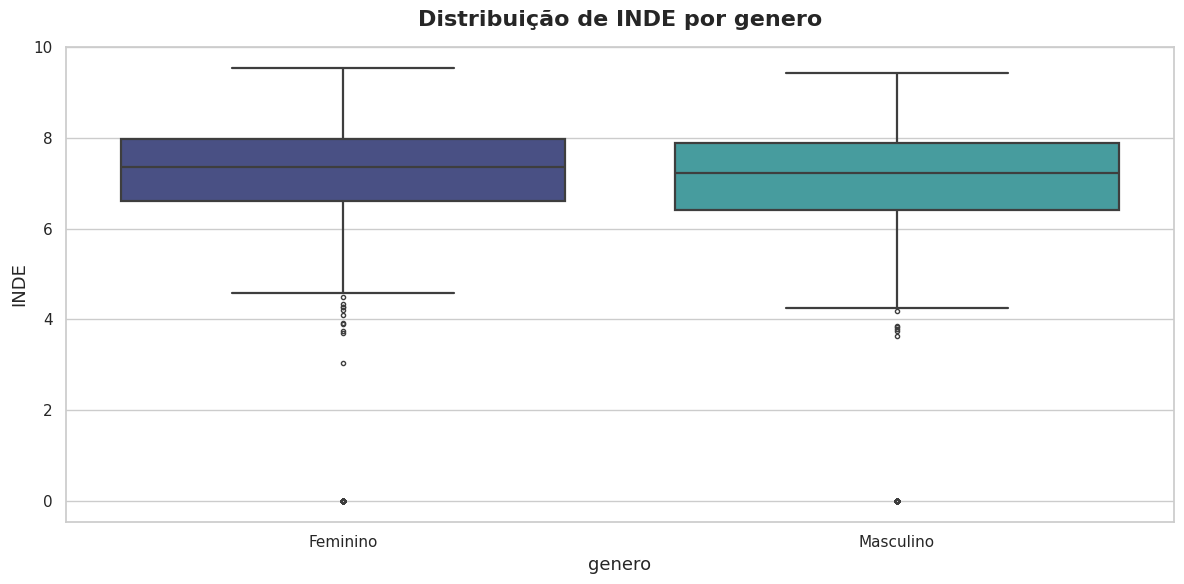

In [9]:
#Gerando um boxplot para verificar a presença de outliers

def plotar_boxplot(df, x, y):

    # Estilo do gráfico
    sns.set_theme(style="whitegrid")

    plt.figure(figsize=(12, 6))

    # Paleta e parâmetros do gráfico
    sns.boxplot(
        data=df,
        x=x,
        y=y,
        palette="mako",
        linewidth=1.6,
        fliersize=3
    )

    # Título
    plt.title(
        f"Distribuição de {y} por {x}",
        fontsize=16,
        weight='bold',
        pad=15
    )

    # Rotulação das labels dos eixos
    plt.xlabel(x, fontsize=13)
    plt.ylabel(y, fontsize=13)

    # Melhora o espaçamento
    plt.tight_layout()

    plt.show()

#Plota o gráfico

plotar_boxplot(df1, 'genero', 'INDE')

###Gráfico de correlação

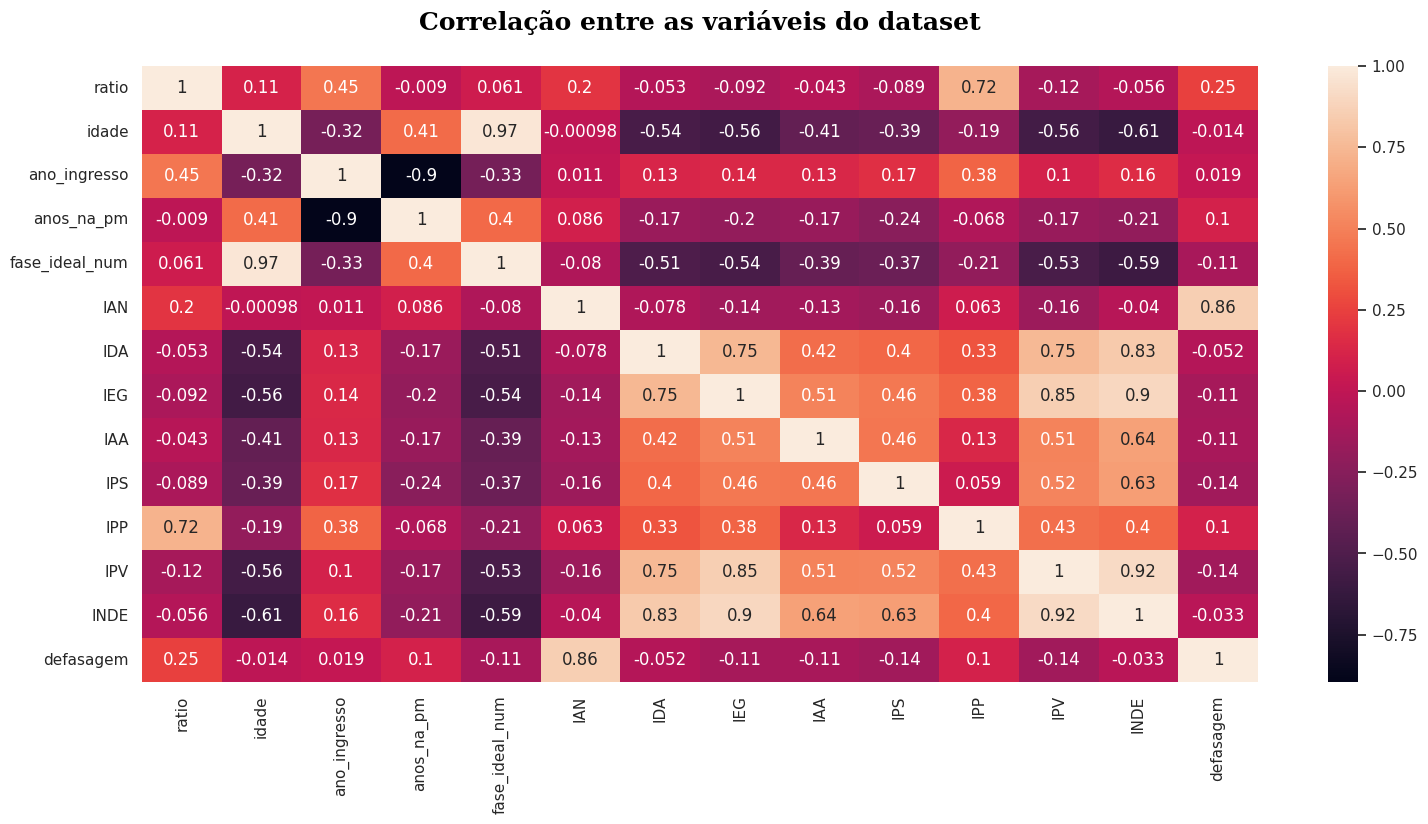

In [11]:

#correlaciona as variáveis do dataframe
df1.corr(numeric_only=True)

#alterar a fonte e tamanho do título

fonte_titulo = {
    'family': 'serif',
    'color': 'black',
    'weight': 'bold',
    'size': 18
}


#plota um heatmap
plt.figure(figsize=(18,8))
sns.heatmap(df1.corr(numeric_only=True), annot=True, cmap='rocket')
plt.title("Correlação entre as variáveis do dataset\n", fontdict=fonte_titulo)
plt.show()

#Respondendo as perguntas propostas

##Pergunta 1

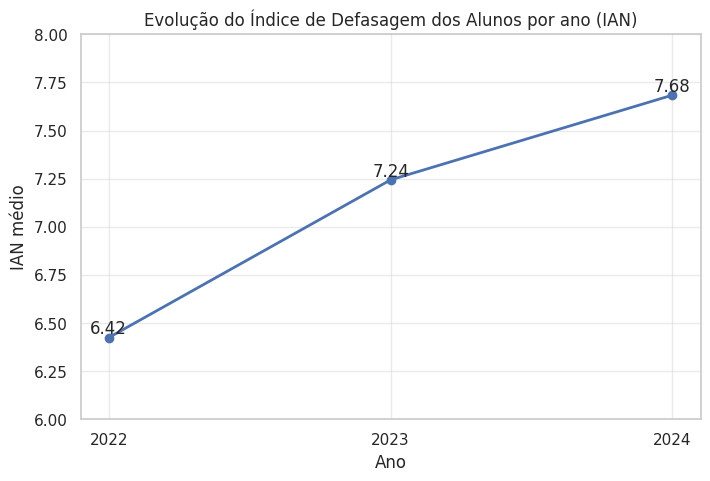

In [ ]:
# 1.   Adequação do nível (IAN): Qual é o perfil geral de defasagem dos alunos (IAN) e como ele evolui ao longo do ano?

#df com a média de IAN por ano
IAN_por_ano = df1.groupby('ratio')['IAN'].mean().reset_index()


#Plota o gráfico de linhas
plt.figure(figsize=(8,5))
plt.plot(IAN_por_ano['ratio'], IAN_por_ano['IAN'], marker='o', linewidth=2)

plt.title('Evolução do Índice de Defasagem dos Alunos por ano (IAN)')
plt.xlabel('Ano')
plt.ylabel('IAN médio')

plt.xticks(IAN_por_ano['ratio'])
plt.ylim(6.0, 8.0)

plt.grid(True, which='major', alpha=0.4)

for x, y in zip(IAN_por_ano['ratio'], IAN_por_ano['IAN']):
    plt.text(x, y + 0.02, f'{y:.2f}', ha='center')

plt.show()

##Pergunta 2

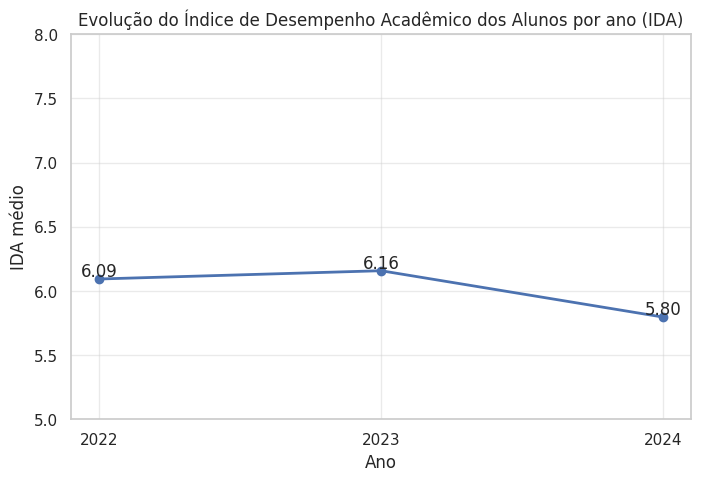

In [ ]:
#2. Desempenho acadêmico (IDA): O desempenho acadêmico médio (IDA) está melhorando, estagnado ou caindo ao longo das fases e anos?


#dataframe com a média de IDA por ano
IDA_por_ano = df1.groupby('ratio')['IDA'].mean().reset_index()

#plota o gráfico de linhas
plt.figure(figsize=(8,5))
plt.plot(IDA_por_ano['ratio'], IDA_por_ano['IDA'], marker='o', linewidth=2)

plt.title('Evolução do Índice de Desempenho Acadêmico dos Alunos por ano (IDA)')
plt.xlabel('Ano')
plt.ylabel('IDA médio')

plt.xticks(IDA_por_ano['ratio'])
plt.ylim(5.0, 8.0)

plt.grid(True, which='major', alpha=0.4)

for x, y in zip(IDA_por_ano['ratio'], IDA_por_ano['IDA']):
    plt.text(x, y + 0.02, f'{y:.2f}', ha='center')

plt.show()

##Pergunta 3


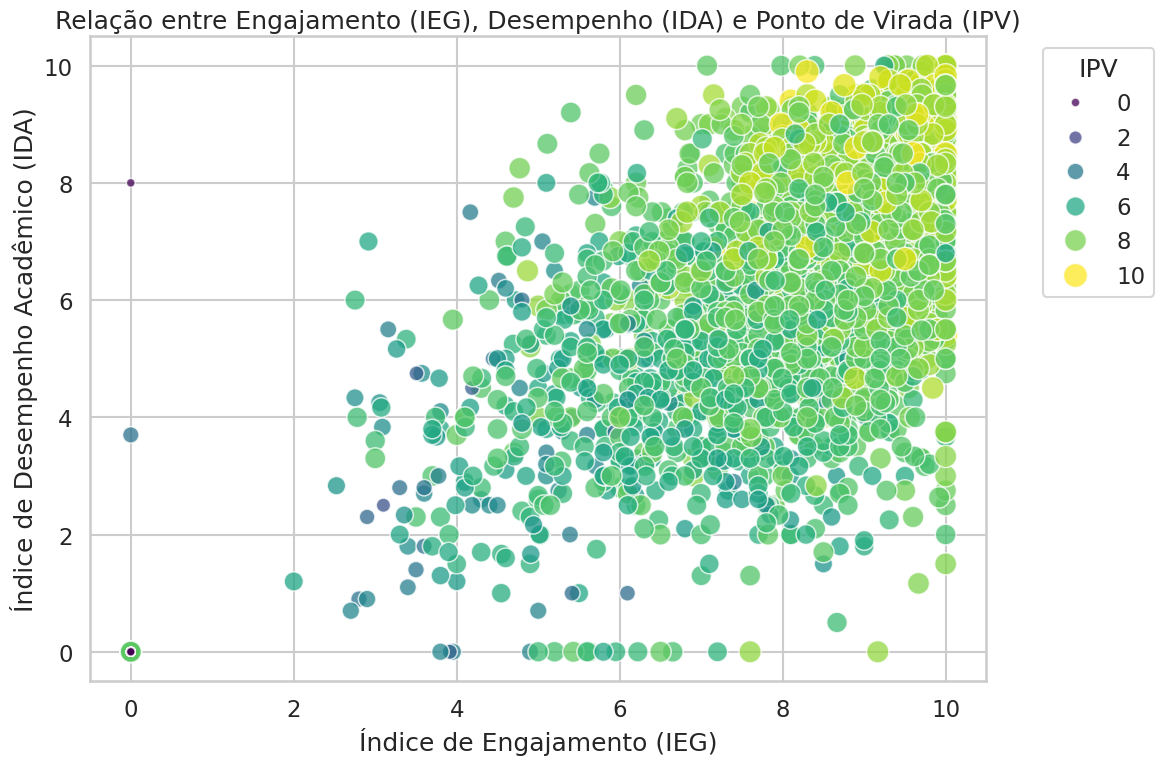

In [ ]:
#3. Engajamento nas atividades (IEG): O grau de engajamento dos alunos (IEG) tem relação direta com seus indicadores de desempenho (IDA) e do ponto de virada (IPV)?


#construção scatterplot

sns.set_theme(style="whitegrid", context="talk")

plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=df1,
    x="IEG",
    y="IDA",
    hue="IPV",
    size="IPV",
    palette="viridis",
    sizes=(40, 300),
    alpha=0.75
)

plt.title("Relação entre Engajamento (IEG), Desempenho (IDA) e Ponto de Virada (IPV)")
plt.xlabel("Índice de Engajamento (IEG)")
plt.ylabel("Índice de Desempenho Acadêmico (IDA)")
plt.legend(title="IPV", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


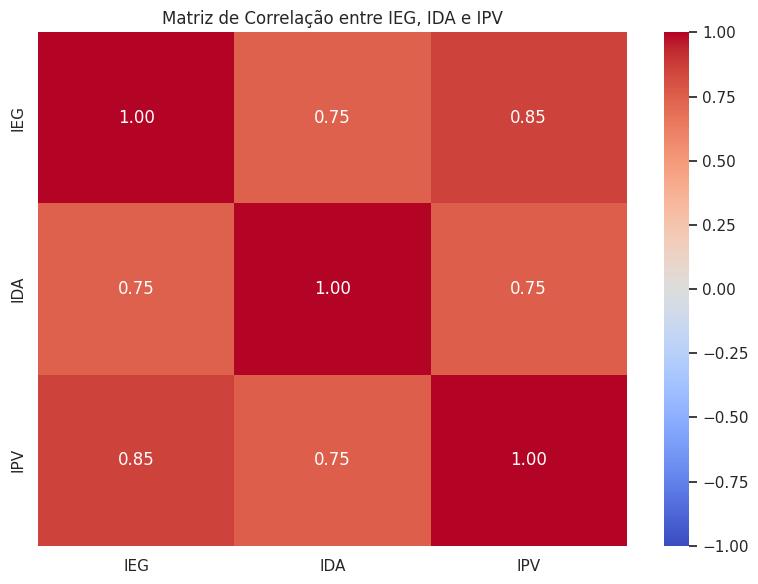

In [ ]:
#Heatmap para melhor entendimento da correlação

plt.figure(figsize=(8, 6))

corr = df1[["IEG", "IDA", "IPV"]].corr(method="pearson")

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    vmin=-1,
    vmax=1
)

plt.title("Matriz de Correlação entre IEG, IDA e IPV")
plt.tight_layout()
plt.show()

##Pergunta 4


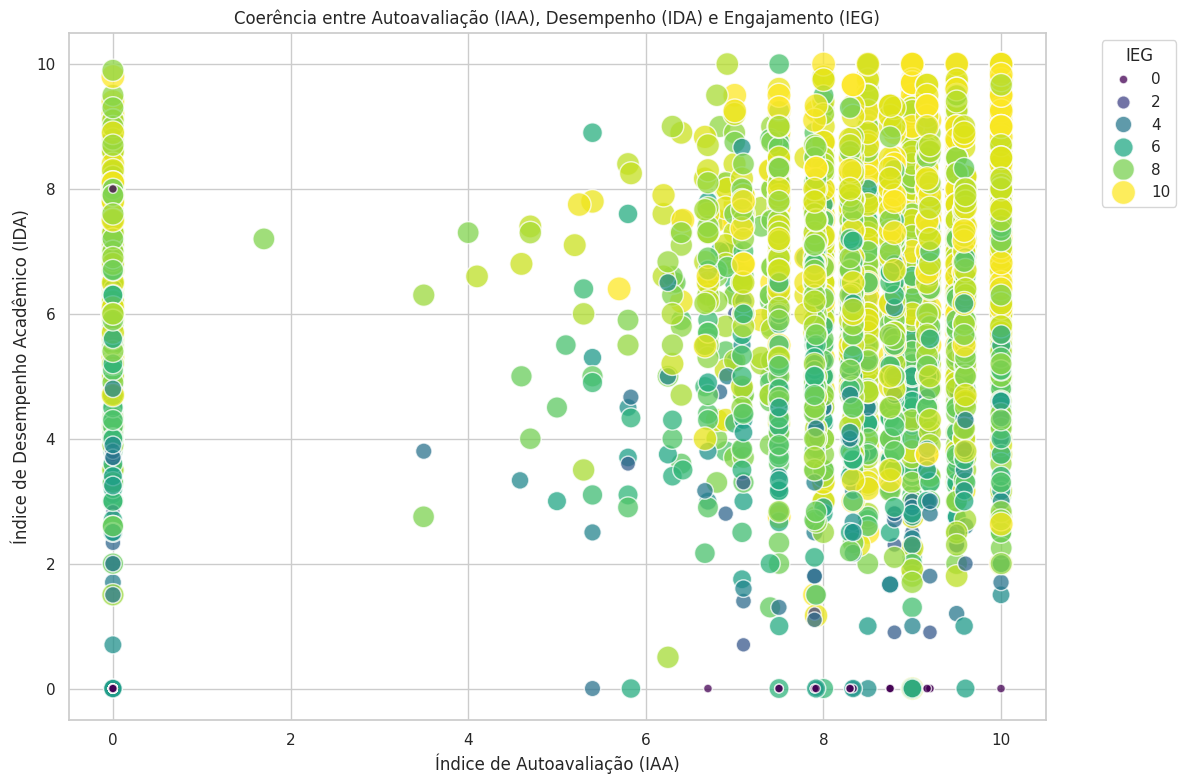

In [ ]:
# 4. Autoavaliação (IAA): As percepções dos alunos sobre si mesmos (IAA) são coerentes com seu desempenho real (IDA) e engajamento (IEG)?

plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=df1,
    x="IAA",
    y="IDA",
    hue="IEG",
    size="IEG",
    palette="viridis",
    sizes=(40, 300),
    alpha=0.75
)

plt.title("Coerência entre Autoavaliação (IAA), Desempenho (IDA) e Engajamento (IEG)")
plt.xlabel("Índice de Autoavaliação (IAA)")
plt.ylabel("Índice de Desempenho Acadêmico (IDA)")
plt.legend(title="IEG", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

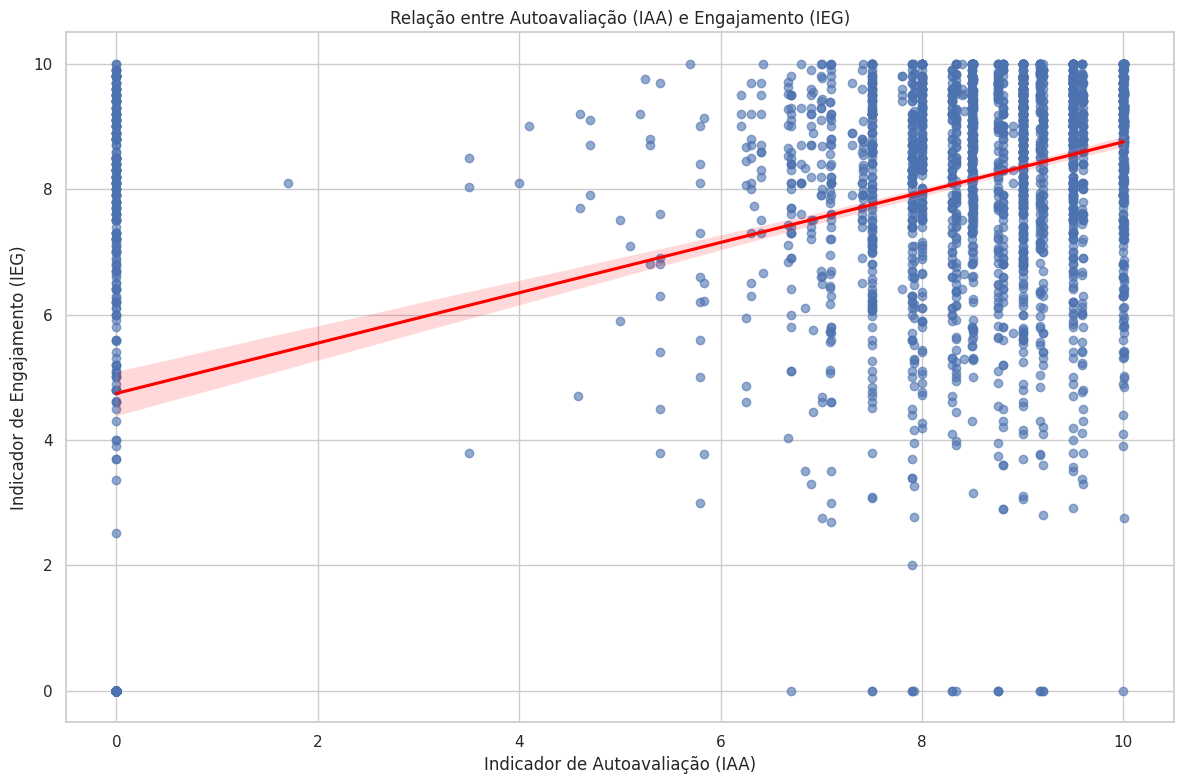

In [ ]:
plt.figure(figsize=(12, 8))

sns.regplot(
    data=df1,
    x="IAA",
    y="IEG",
    scatter_kws={"alpha": 0.6},
    line_kws={"color": "red"}
)

plt.title("Relação entre Autoavaliação (IAA) e Engajamento (IEG)")
plt.xlabel("Indicador de Autoavaliação (IAA)")
plt.ylabel("Indicador de Engajamento (IEG)")
plt.tight_layout()
plt.show()

##Pergunta 5

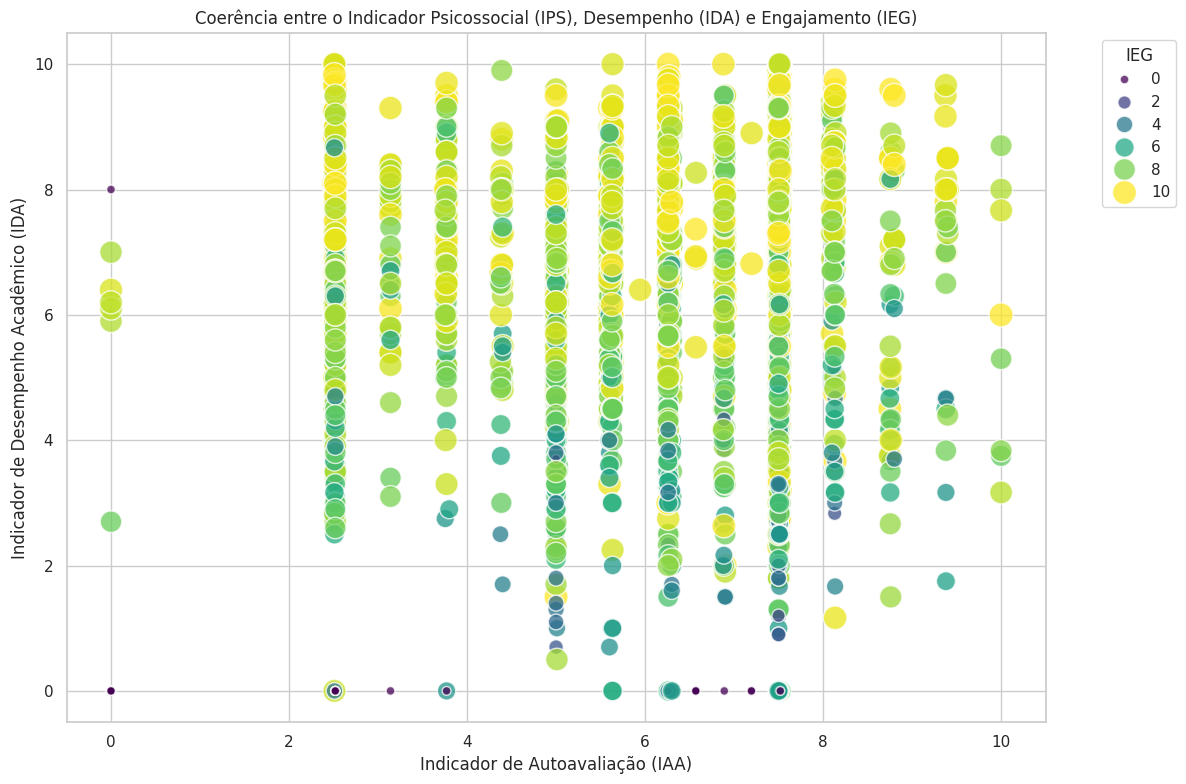

In [ ]:
# 5. Aspectos psicossociais (IPS): Há padrões psicossociais (IPS) que antecedem quedas de desempenho acadêmico ou de engajamento?


plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=df1,
    x="IPS",
    y="IDA",
    hue="IEG",
    size="IEG",
    palette="viridis",
    sizes=(40, 300),
    alpha=0.75
)

plt.title("Coerência entre o Indicador Psicossocial (IPS), Desempenho (IDA) e Engajamento (IEG)")
plt.xlabel("Indicador de Autoavaliação (IAA)")
plt.ylabel("Indicador de Desempenho Acadêmico (IDA)")
plt.legend(title="IEG", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


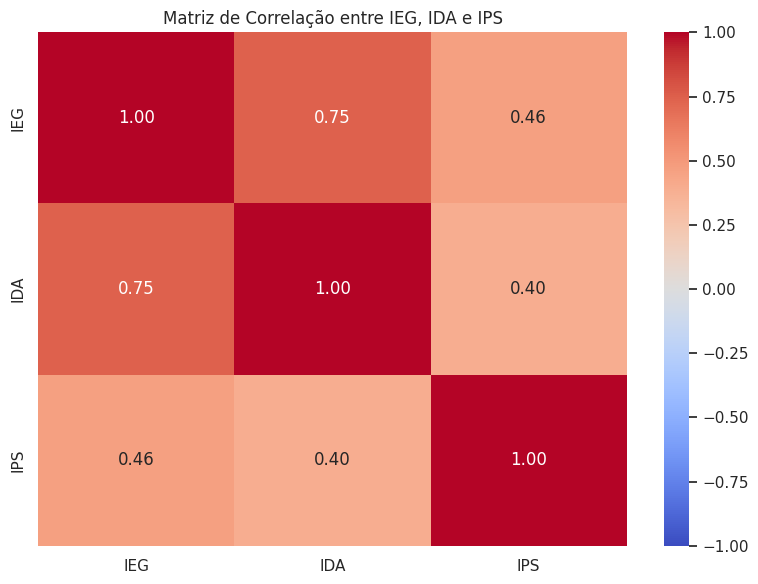

In [ ]:
#Heatmap para melhor entendimento da correlação

plt.figure(figsize=(8, 6))

corr = df1[["IEG", "IDA", "IPS"]].corr(method="pearson")

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    vmin=-1,
    vmax=1
)

plt.title("Matriz de Correlação entre IEG, IDA e IPS")
plt.tight_layout()
plt.show()

##Pergunta 6

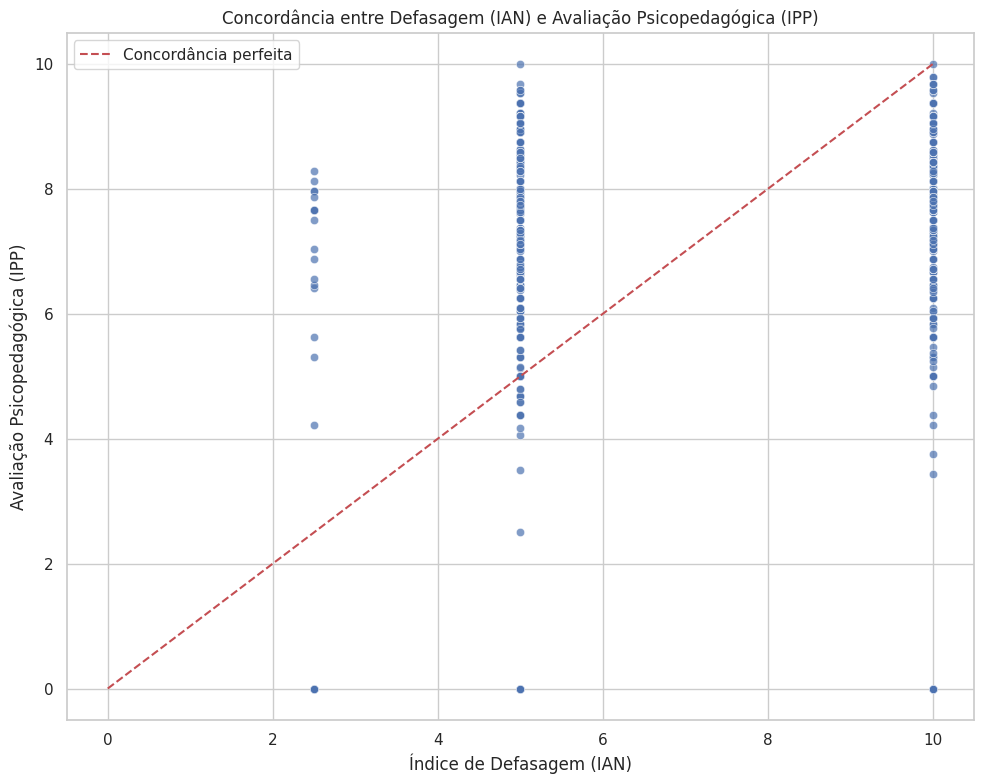

In [ ]:
# 6. Aspectos psicopedagógicos (IPP): As avaliações psicopedagógicas (IPP) confirmam ou contradizem a defasagem identificada pelo IAN?


plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=df1,
    x="IAN",
    y="IPP",
    alpha=0.7
)

# Linha de concordância perfeita (y = x)
min_val = min(df0["IAN"].min(), df0["IPP"].min())
max_val = max(df0["IAN"].max(), df0["IPP"].max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label="Concordância perfeita")

plt.title("Concordância entre Defasagem (IAN) e Avaliação Psicopedagógica (IPP)")
plt.xlabel("Índice de Defasagem (IAN)")
plt.ylabel("Avaliação Psicopedagógica (IPP)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

##Pergunta 7

/tmp/ipython-input-170/3934984620.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x['valor'].corr(x['IPV']))


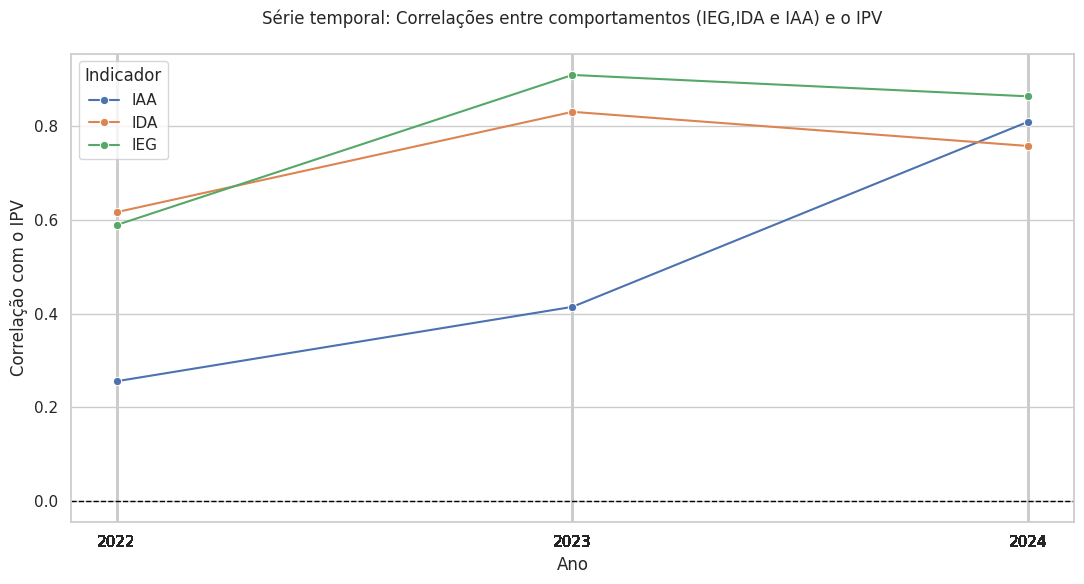

In [ ]:
# 7. Ponto de virada (IPV): Quais comportamentos - acadêmicos, emocionais ou de engajamento - mais influenciam o IPV ao longo do tempo?



# Mapeamento conceitual (para legenda e interpretação)
variaveis = {
    'IEG': 'Engajamento',
    'IDA': 'Acadêmico',
    'IAA': 'Autoavaliação'}

#Contrução do dataframe de correlação por ano

corr_df = (
    df1.melt(
        id_vars=['ratio', 'IPV'],
        value_vars=list(variaveis.keys()),
        var_name='indicador',
        value_name='valor'
            )
       .groupby(['ratio', 'indicador'])
       .apply(lambda x: x['valor'].corr(x['IPV']))
       .reset_index(name='correlacao')
          )


#Gráfico de linhas

sns.set_theme(style="whitegrid")

plt.figure(figsize=(11, 6))

sns.lineplot(
    data=corr_df,
    x='ratio',
    y='correlacao',
    hue='indicador',
    marker='o'
            )

plt.axhline(0, linestyle='--', color='black', linewidth=1)

plt.title(
    'Série temporal: Correlações entre comportamentos (IEG,IDA e IAA) e o IPV\n'
         )

plt.xlabel('Ano')
plt.xticks(df1['ratio'])
plt.ylabel('Correlação com o IPV')
plt.legend(title='Indicador')

plt.tight_layout()
plt.show()

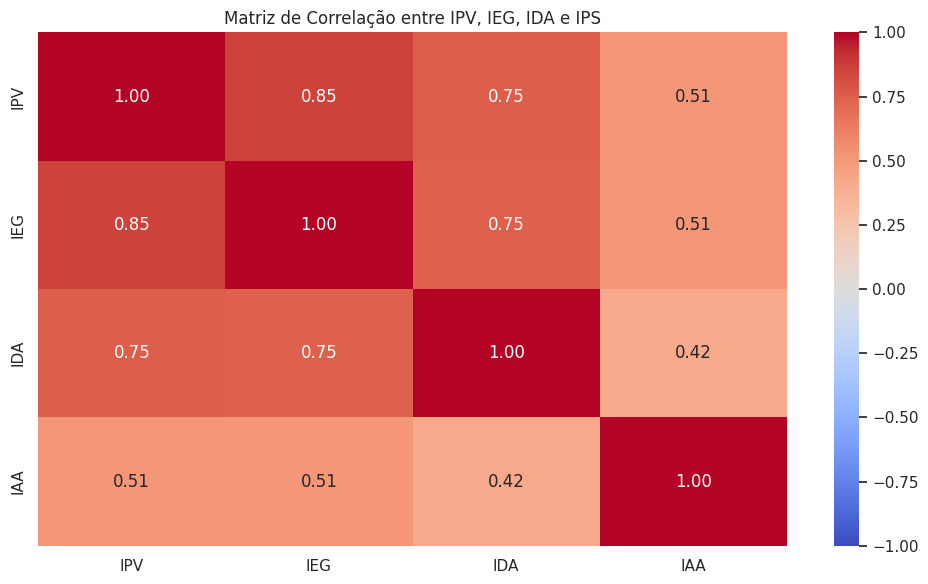

In [ ]:
#Heatmap para melhor entendimento da correlação

plt.figure(figsize=(10, 6))

corr = df1[['IPV', "IEG", "IDA", "IAA"]].corr(method="pearson")

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    vmin=-1,
    vmax=1
)

plt.title("Matriz de Correlação entre IPV, IEG, IDA e IPS")
plt.tight_layout()
plt.show()

##Pergunta 8

####Base de trabalho

In [ ]:
# 8. Multidimensionalidade dos indicadores: Quais combinações de indicadores (IDA + IEG + IPS + IPP) elevam mais a nota global do aluno (INDE)?

# Faixas de correlação

for col in ['IDA', 'IEG', 'IPS', 'IPP']:
    df1[col + '_bin'] = pd.cut(
        df1[col],
        bins=[0, 3.33, 6.66, 10],
        labels=['Baixo', 'Médio', 'Alto'],
        include_lowest=True
    )


#Função de trabalho

def plotar_heatmap_corr(col1, col2):

    heatmap_df = (
        df1.groupby([col1, col2])['INDE']
          .mean()
          .reset_index()
          .pivot(index=col1, columns=col2, values='INDE')
    )

    plt.figure(figsize=(8, 6))
    sns.heatmap(heatmap_df, annot=True, cmap='viridis')
    plt.title(f'INDE médio por combinação de {col1} e {col2}')
    plt.xlabel(col2)
    plt.ylabel(col1)
    plt.tight_layout()
    plt.show()




####IDA + IEG X INDE  

/tmp/ipython-input-170/1396115589.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df1.groupby([col1, col2])['INDE']


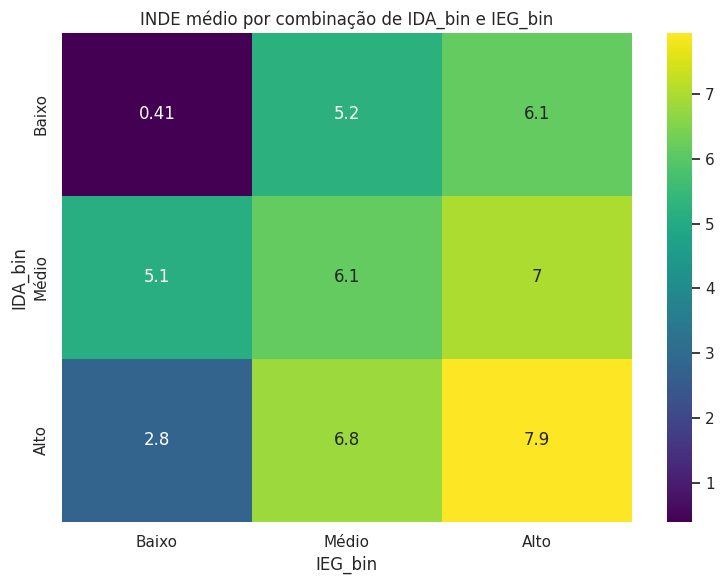

In [ ]:

#############################
#     IDA + IEG X INDE      #
#############################

plotar_heatmap_corr('IDA_bin', 'IEG_bin')


#### IDA + IPS X INDE

/tmp/ipython-input-170/3320497845.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df0.groupby(['IDA_bin', 'IPS_bin'])


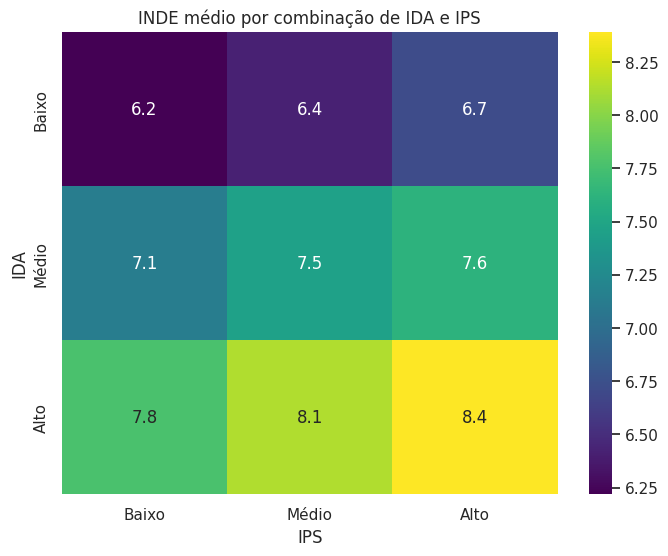

In [ ]:

#############################
#     IDA + IPS X INDE      #
#############################


#Heatmap

plotar_heatmap_corr('IDA_bin', 'IPS_bin')

####IDA + IPP X INDE

/tmp/ipython-input-170/1396115589.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df1.groupby([col1, col2])['INDE']


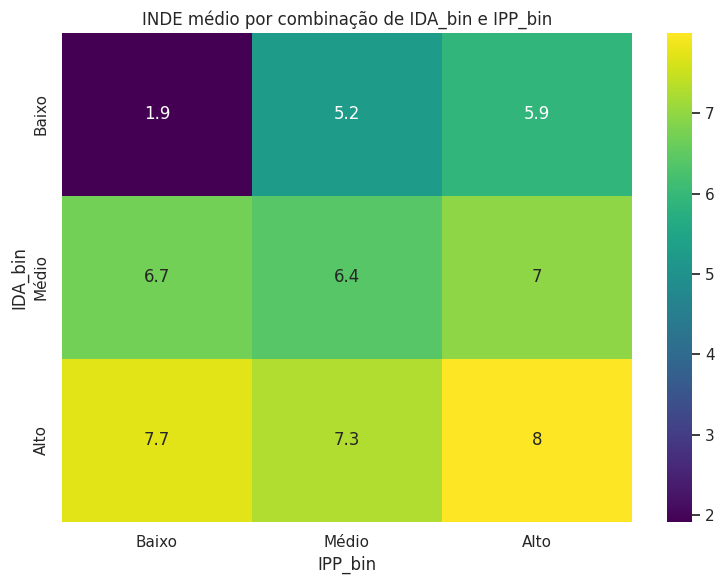

In [ ]:

#############################
#     IDA + IPP X INDE      #
#############################

#Heatmap

plotar_heatmap_corr('IDA_bin', 'IPP_bin')

####IEG + IPS X INDE

/tmp/ipython-input-170/1396115589.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df1.groupby([col1, col2])['INDE']


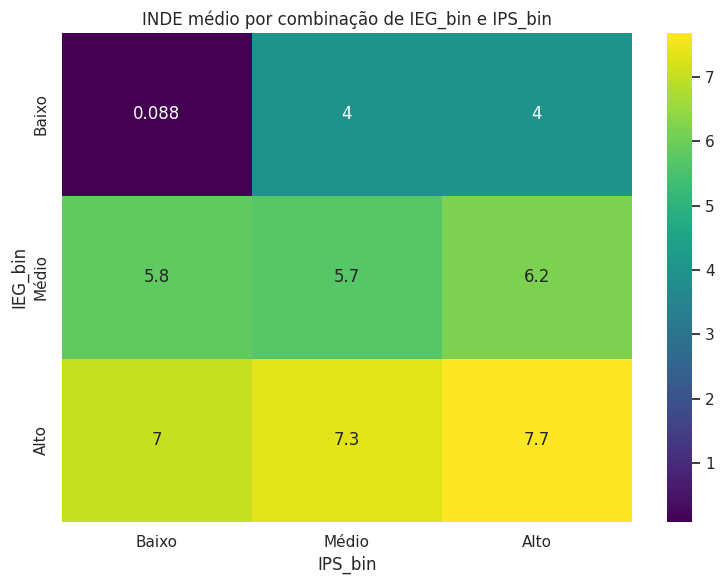

In [ ]:

#############################
#     IEG + IPS X INDE      #
#############################

plotar_heatmap_corr('IEG_bin', 'IPS_bin')

####IEG + IPP X INDE  

/tmp/ipython-input-170/1396115589.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df1.groupby([col1, col2])['INDE']


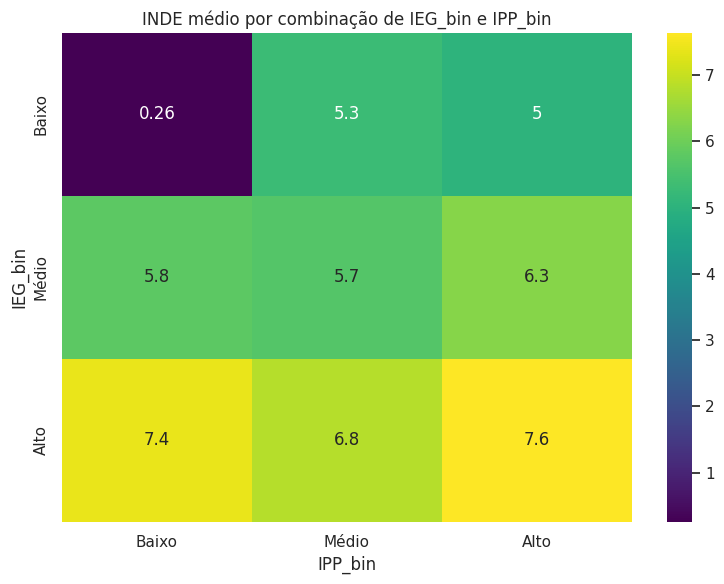

In [ ]:

#############################
#     IEG + IPP X INDE      #
#############################

plotar_heatmap_corr('IEG_bin', 'IPP_bin')

####IPS + IPP X INDE  

/tmp/ipython-input-170/1396115589.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df1.groupby([col1, col2])['INDE']


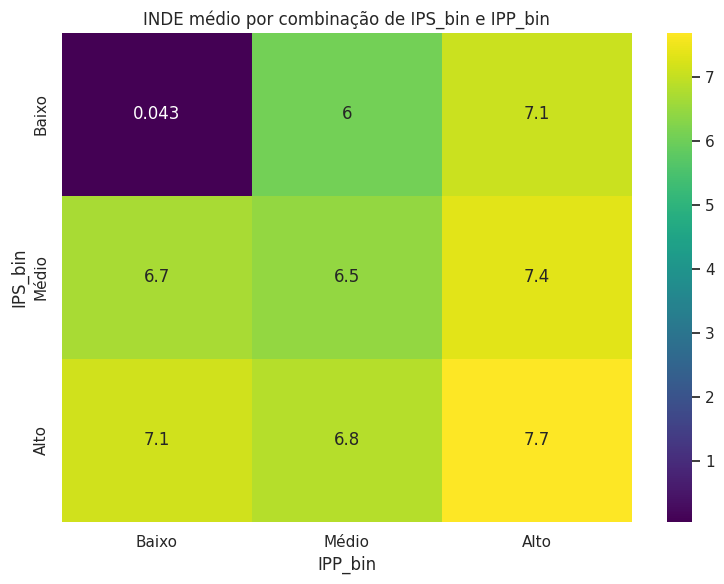

In [ ]:

#############################
#     IPS + IPP X INDE      #
#############################

plotar_heatmap_corr('IPS_bin', 'IPP_bin')

In [ ]:
heatmap_df.dropna(inplace=True)


heatmap_df

ratio,2022,2023,2024
pedra,,,
Topazio,8.366546,8.441459,8.467623
Ametista,7.528437,7.510856,7.534213
Agata,6.606000,6.569258,6.599913
Quartzo,5.242909,5.549967,5.400035


##Pergunta 10

In [17]:
# Média anual do INDE por pedra
df_time = (
    df1.groupby(['ratio', 'pedra'])
      .INDE.mean()
      .sort_values(ascending=False)
      .reset_index()
)

df_time.head()

,ratio,pedra,INDE
0,2024,Topazio,8.467623
1,2023,Topazio,8.441459
2,2022,Topazio,8.366546
3,2024,Ametista,7.534213
4,2022,Ametista,7.528437


<Figure size 1200x700 with 0 Axes>

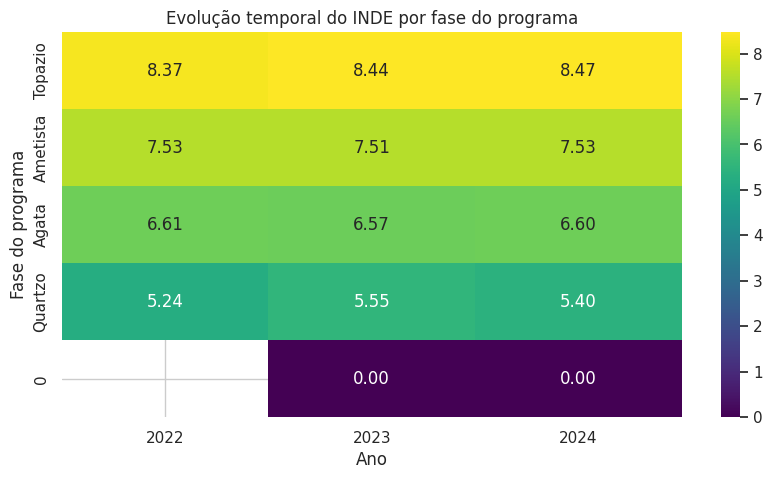

In [14]:
#10. Efetividade do programa: Os indicadores mostram melhora consistente ao longo do ciclo nas diferentes fases (Quartzo, Ágata, Ametista e Topázio), confirmando o impacto real do programa?



ordem_pedra = (
    df_time
    .groupby('pedra')['INDE']
    .mean()
    .sort_values(ascending=False)
    .index
    )


plt.figure(figsize=(12,7))

heatmap_df = df_time.pivot(
    index='pedra',
    columns='ratio',
    values='INDE'
).loc[ordem_pedra]


plt.figure(figsize=(10,5))
sns.heatmap(
    heatmap_df,
    cmap='viridis',
    annot=True,
    fmt='.2f'
)

plt.title('Evolução temporal do INDE por fase do programa')
plt.xlabel('Ano')
plt.ylabel('Fase do programa')
plt.show()


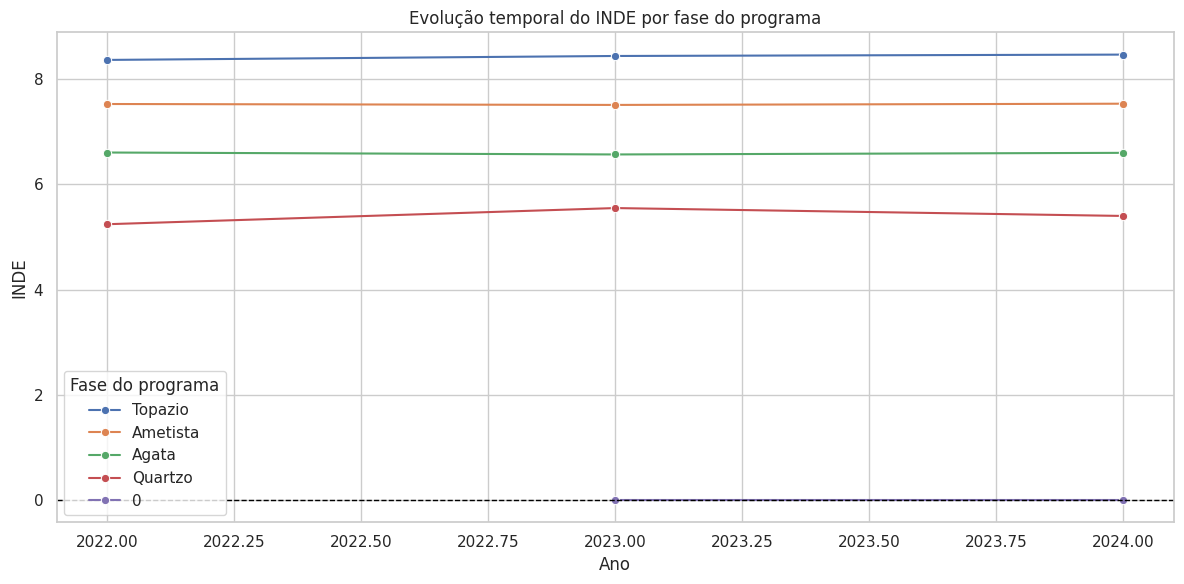

In [22]:
#Gráfico de linhas

sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df_time,
    x='ratio',
    y='INDE',
    hue='pedra',
    marker='o'
            )
plt.axhline(0, linestyle='--', color='black', linewidth=1)

plt.title('Evolução temporal do INDE por fase do programa')
plt.xlabel('Ano')
plt.ylabel('INDE')
plt.legend(title='Fase do programa', loc='lower left')

plt.tight_layout()
plt.show()

##Pergunta 11

###Gráficos - Insights extras

###Evolução das notas por ano

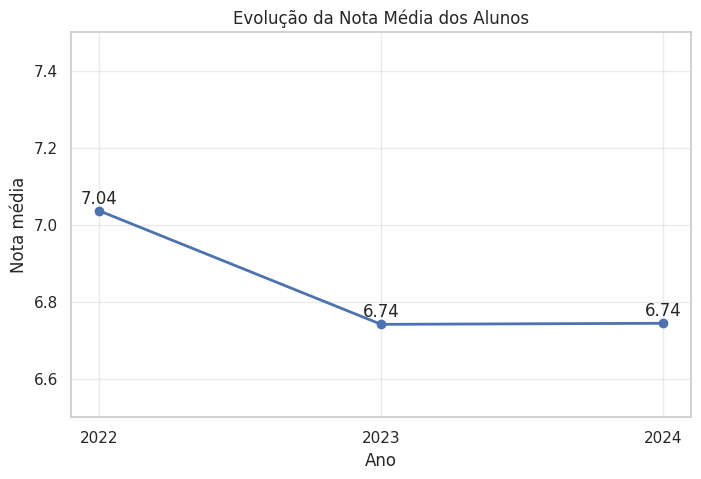

In [24]:
media_por_ano = df1.groupby('ratio')['INDE'].mean().reset_index()


plt.figure(figsize=(8,5))
plt.plot(media_por_ano['ratio'], media_por_ano['INDE'], marker='o', linewidth=2)

plt.title('Evolução da Nota Média dos Alunos')
plt.xlabel('Ano')
plt.ylabel('Nota média')

plt.xticks(media_por_ano['ratio'])
plt.ylim(6.5, 7.5)

plt.grid(True, which='major', alpha=0.4)

for x, y in zip(media_por_ano['ratio'], media_por_ano['INDE']):
    plt.text(x, y + 0.02, f'{y:.2f}', ha='center')

plt.show()

###Disposição de alunos por tipo de instituição de ensino

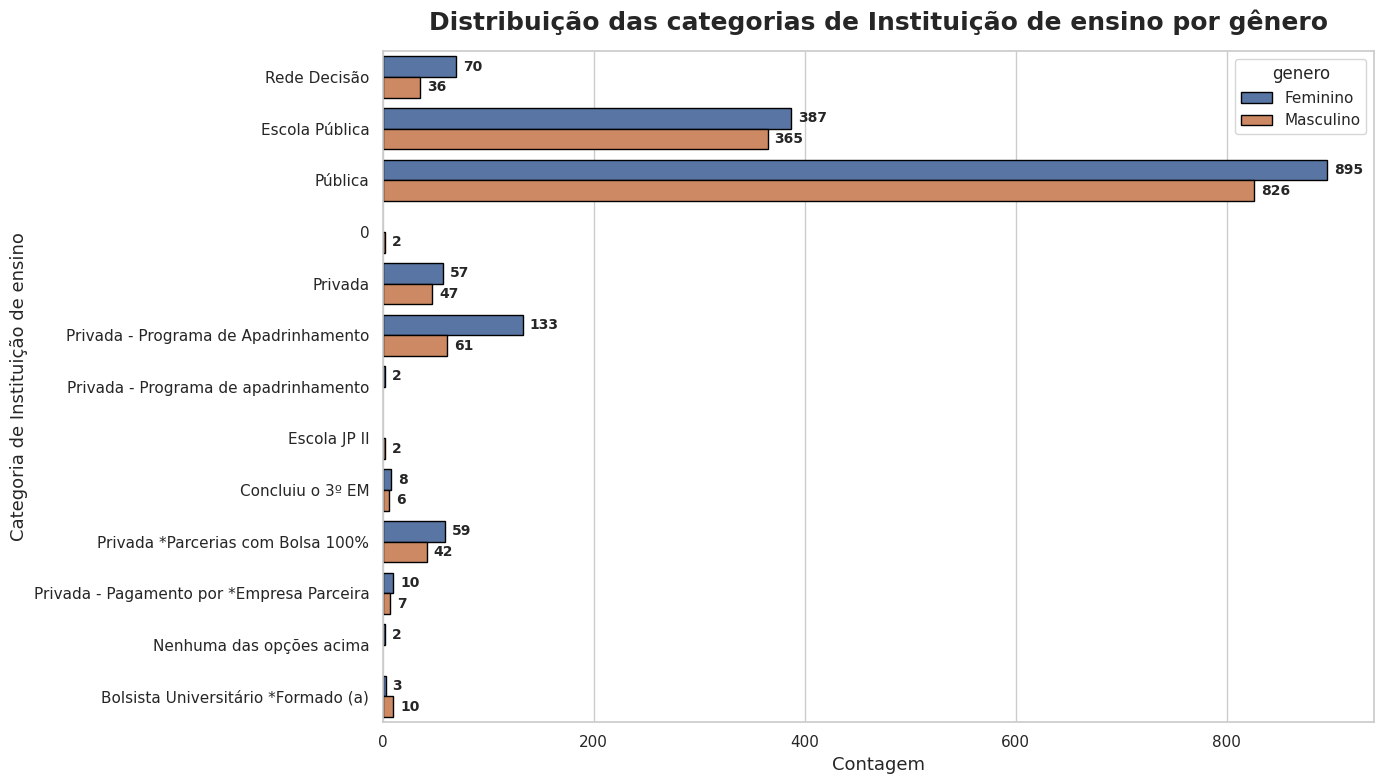

In [27]:
def plotar_obesidade_por_genero(
    df,
    genero_col='genero',
    inst_ensino_col='instituicao_ensino'
):


    df_plot = df.dropna(subset=[genero_col, inst_ensino_col]).copy()

    # Normalização CRÍTICA
    df_plot[genero_col] = (
        df_plot[genero_col]
        .str.strip()
        .str.capitalize()
    )

    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(14, 8))

    ax = sns.countplot(
        data=df_plot,
        y=inst_ensino_col,
        hue=genero_col,
        edgecolor="black"
    )

    plt.title(
        "Distribuição das categorias de Instituição de ensino por gênero",
        fontsize=18,
        weight='bold',
        pad=15
    )

    plt.xlabel("Contagem", fontsize=13)
    plt.ylabel("Categoria de Instituição de ensino", fontsize=13)

    # Rótulos nas barras (horizontal)
    for p in ax.patches:
        width = p.get_width()
        if width > 0:
            ax.annotate(
                f'{int(width)}',
                (width, p.get_y() + p.get_height() / 2),
                ha='left',
                va='center',
                fontsize=10,
                weight='bold',
                xytext=(5, 0),
                textcoords='offset points'
            )

    plt.legend(title="genero")
    plt.tight_layout()
    plt.show()


plotar_obesidade_por_genero(df1)

### Nível de defasagem

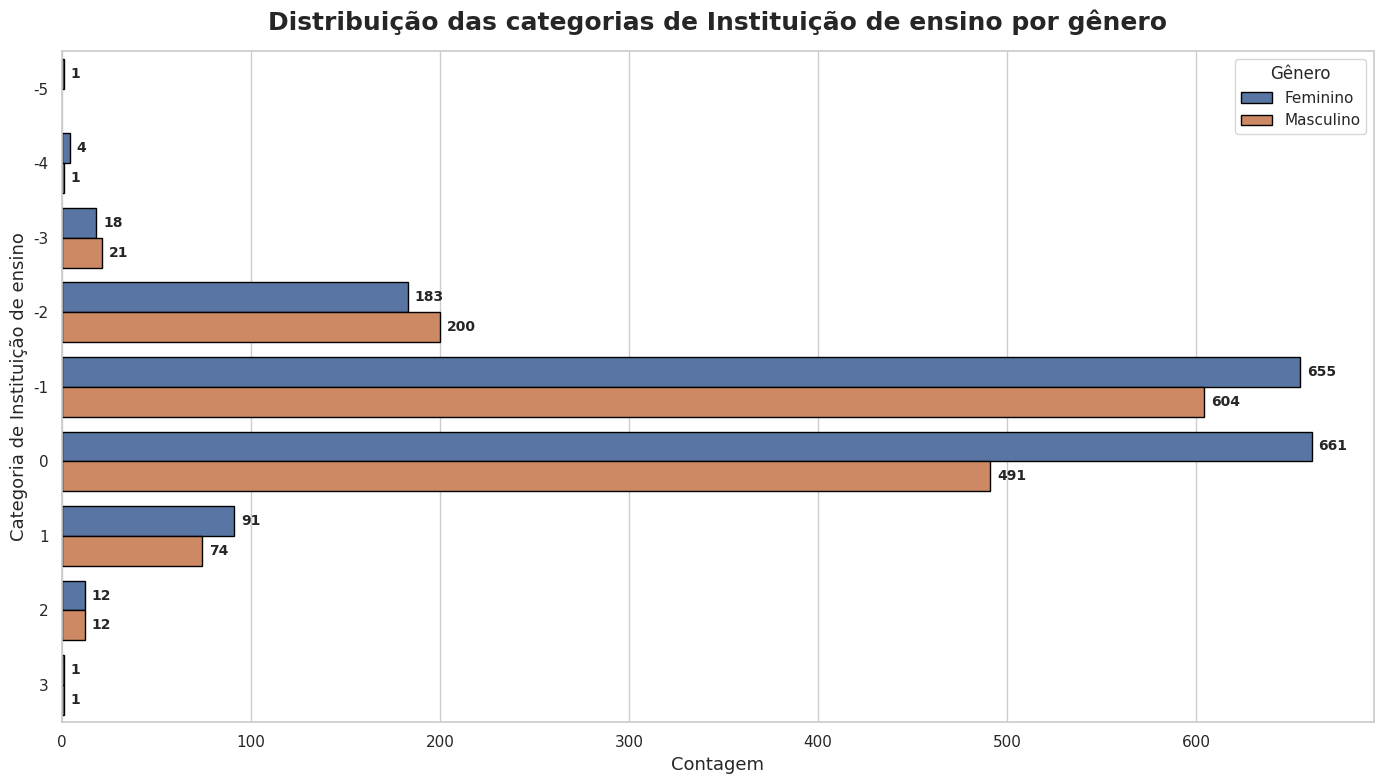

In [28]:
def plotar_obesidade_por_genero(
    df,
    genero_col='genero',
    inst_ensino_col='defasagem'
):
    import seaborn as sns
    import matplotlib.pyplot as plt

    df_plot = df.dropna(subset=[genero_col, inst_ensino_col]).copy()

    # Normalização CRÍTICA
    df_plot[genero_col] = (
        df_plot[genero_col]
        .str.strip()
        .str.capitalize()
    )

    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(14, 8))

    ax = sns.countplot(
        data=df_plot,
        y=inst_ensino_col,
        hue=genero_col,
        edgecolor="black"
    )

    plt.title(
        "Distribuição das categorias de Instituição de ensino por gênero",
        fontsize=18,
        weight='bold',
        pad=15
    )

    plt.xlabel("Contagem", fontsize=13)
    plt.ylabel("Categoria de Instituição de ensino", fontsize=13)

    # Rótulos nas barras (horizontal)
    for p in ax.patches:
        width = p.get_width()
        if width > 0:
            ax.annotate(
                f'{int(width)}',
                (width, p.get_y() + p.get_height() / 2),
                ha='left',
                va='center',
                fontsize=10,
                weight='bold',
                xytext=(5, 0),
                textcoords='offset points'
            )

    plt.legend(title="Gênero")
    plt.tight_layout()
    plt.show()


plotar_obesidade_por_genero(df1)